# Model: Logistic Regression for PERM Visa Denial
**Member:** IT25100285
**Model:** Logistic Regression (`sklearn.linear_model.LogisticRegression`)
**Dataset:** handover **B** `results/outputs/final_processed.csv.gz` (25 selected, scaled features), created by my Stage 6
**Group:** 2026-Y02-S1-MLB-B9G1-08
**Task:** binary classification: `denied` = 1 (Denied) vs 0 (Certified / Certified-Expired)

**Covers:** Step 3 (model design, implementation, hyperparameter tuning, pipeline steps) and Step 4 (metrics, k-fold CV, comparison of model varieties) for my individual Final Evaluation.

---
## 1. Why Logistic Regression suits this dataset

**How it works.** Logistic Regression computes a weighted sum of the features, `z = b0 + b1*x1 + ... + b25*x25`, and squashes it into a probability with the sigmoid `P(denied) = 1 / (1 + e^-z)`. Training finds the weights that best separate denied from approved applications (maximum likelihood), with a penalty that stops weights from growing too large (regularisation, controlled by `C`).

**Why it fits *this* problem:**
1. **Interpretable.** Each coefficient says how a feature changes the *odds* of denial, e.g. "offering below the prevailing wage multiplies the odds of denial by X". That's essential for a government decision process, and for the ethics section of the report.
2. **Built on my feature selection.** Stage 6 removed redundant features (|r| > 0.85), which is exactly what Logistic Regression needs: correlated inputs make its coefficients unstable (multicollinearity). Stage 5 scaling makes the coefficients comparable and helps the solver converge.
3. **Handles imbalance.** Only 6.9% of applications are denied. `class_weight='balanced'` makes each denial count about 13.5× more in the loss.
4. **Fast on 284k rows.** About 1–2 s per fit, so a full grid search with 5-fold CV is affordable.
5. **A strong baseline** for the group comparison against the non-linear models (trees, XGBoost, MLP).

**Known limitation:** it draws a *linear* boundary (in the log-odds). Non-linear effects and feature interactions are only captured where Stage 4 built them into features (e.g. `wage_below_pw`).

## 2. Evaluation design (shared by all six group models)

| Decision | Choice | Why |
|---|---|---|
| Train / test | The `split` column from Stage 1 (stratified 80/20, seed 42) | Every member uses the **same rows**, so the six models are comparable |
| Validation | **5-fold `StratifiedKFold`** (shuffle, seed 42) on the train rows only | The assignment requires k-fold CV; stratified keeps 6.9% denied in every fold |
| Main metric | **PR-AUC** (`average_precision`) | Measures how well denials are ranked above approvals; robust to the rare positive class |
| Also reported | F1, precision and recall for Denied; ROC-AUC; balanced accuracy; accuracy | F1 balances missed denials vs false alarms; accuracy only as a warning sign |
| Test set | Used **once**, at the very end, for the best variety | Using it to make choices would make the reported score optimistic |

**The accuracy trap:** the dataset is 93.1% approved, so a model that *always* predicts "approved" scores 93.1% accuracy while catching **zero** denials. Variety V0 below demonstrates exactly this.

### Block 1: Setup
Imports, paths and the shared settings (same `SEED` and CV as every teammate).

In [1]:
import os
import json
import time
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score, precision_score, recall_score,
                             accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report,
                             precision_recall_curve, roc_curve, ConfusionMatrixDisplay, make_scorer)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, 'data', 'raw')) and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
OUT_DIR = os.path.join(ROOT, 'results', 'outputs')
MODEL_DIR = os.path.join(ROOT, 'results', 'models', 'IT25100285_LogisticRegression')
os.makedirs(MODEL_DIR, exist_ok=True)

TARGET, SEED = 'denied', 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
SCORING = {'pr_auc': 'average_precision', 'roc_auc': 'roc_auc', 'f1': 'f1',
           'precision': make_scorer(precision_score, zero_division=0),   # V0 predicts no denials -> precision 0, no warning
           'recall': 'recall', 'balanced_acc': 'balanced_accuracy', 'accuracy': 'accuracy'}
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
warnings.filterwarnings('ignore', category=FutureWarning)
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning,ignore::FutureWarning'   # also silence parallel CV workers
print('Results folder:', MODEL_DIR)

Results folder: /Users/jathushansundararasu/Desktop/us_prem_visa/results/models/IT25100285_LogisticRegression


### Block 2: Load the handover datasets
**What:** load handover B (my main dataset) and handover A (all 107 unscaled features, used only for variety V5), then split them with the shared `split` column.
**Why:** no new `train_test_split`. The split was fixed in Stage 1, so every group member trains and tests on identical rows.

In [2]:
def load_handover(version):
    name = {'A': 'cleaned_unscaled_allfeatures.csv.gz', 'B': 'final_processed.csv.gz'}[version]
    df = pd.read_csv(os.path.join(OUT_DIR, name))
    train, test = df[df['split'].eq('train')], df[df['split'].eq('test')]
    return (train.drop(columns=[TARGET, 'split']), train[TARGET],
            test.drop(columns=[TARGET, 'split']), test[TARGET])

X_train, y_train, X_test, y_test = load_handover('B')
X_train_A, y_train_A, X_test_A, y_test_A = load_handover('A')
assert y_train.equals(y_train_A) and y_test.equals(y_test_A), 'A and B must share identical rows'

print(f'Handover B: X_train {X_train.shape}, X_test {X_test.shape}')
print(f'Handover A: X_train {X_train_A.shape}')
print(f'Denied rate - train {y_train.mean():.2%} | test {y_test.mean():.2%}')
print(f'"Always approve" accuracy on test: {1 - y_test.mean():.2%}')

Handover B: X_train (283879, 25), X_test (70970, 25)
Handover A: X_train (283879, 107)
Denied rate - train 6.91% | test 6.91%
"Always approve" accuracy on test: 93.09%


### Block 3: A helper that scores any model with 5-fold CV
**What:** `cross_validate` trains the model 5 times; each time it holds out one fold of the **train** rows and scores on it. We record the mean ± standard deviation of every metric.
**Why:** one function means every variety is scored identically. The standard deviation shows how *stable* a result is across folds.

Note: F1, precision and recall here use the default 0.5 probability threshold; PR-AUC and ROC-AUC are threshold-free.

In [3]:
results = []          # one row per variety
fitted = {}           # name -> (estimator, X_train, X_test) for later use

def evaluate_cv(name, description, estimator, X, y, X_te):
    t = time.time()
    cv = cross_validate(estimator, X, y, cv=CV, scoring=SCORING, n_jobs=-1)
    row = {'variety': name, 'description': description}
    for m in SCORING:
        row[f'{m}_mean'] = cv[f'test_{m}'].mean()
        row[f'{m}_std'] = cv[f'test_{m}'].std()
    row['seconds'] = round(time.time() - t, 1)
    results.append(row)
    fitted[name] = (estimator, X, X_te)
    print(f"{name}: PR-AUC {row['pr_auc_mean']:.3f} ± {row['pr_auc_std']:.3f} | F1 {row['f1_mean']:.3f} | "
          f"recall {row['recall_mean']:.3f} | precision {row['precision_mean']:.3f} | accuracy {row['accuracy_mean']:.3f} "
          f"({row['seconds']}s)")
    return row

## 3. Model varieties (Final Evaluation: "different pre-processing and hyperparameter tune-ups")

| Variety | Data | What changes | Question it answers |
|---|---|---|---|
| **V0** | B | `DummyClassifier`: always predicts "approved" | What does a useless model score? (the accuracy trap) |
| **V1** | B | Plain Logistic Regression, default settings | What happens if we ignore the imbalance? |
| **V2** | B | `class_weight='balanced'` | Does re-weighting the rare class help? |
| **V3** | B | `GridSearchCV` over `C` × `l1_ratio` (L2 / elastic-net / L1) | What are the best hyperparameters? |
| **V4** | B | SMOTE oversampling inside an `imblearn` Pipeline + best V3 settings | Is synthetic oversampling better than class weights? |
| **V5** | **A** | `StandardScaler` + Logistic Regression on all 107 features (Pipeline) | Did my Stage 6 feature selection help or hurt? (experiment only, not eligible as the final model) |
| **V6** | B minus `pwsrc_*` | Ablation: V3 settings without the prevailing-wage-source columns | How much does the "incomplete application" shortcut contribute? |

### Block 4: V0 baseline and V1 plain Logistic Regression
**Expect:** V0 has ~93% accuracy but 0 recall, which proves accuracy is meaningless here. V1 learns *something*, but because denials are rare it rarely predicts "denied", so recall stays low.

In [4]:
evaluate_cv('V0', 'Dummy: always approve', DummyClassifier(strategy='most_frequent'), X_train, y_train, X_test)
evaluate_cv('V1', 'Plain LR (no class weights)', LogisticRegression(max_iter=3000), X_train, y_train, X_test)

V0: PR-AUC 0.069 ± 0.000 | F1 0.000 | recall 0.000 | precision 0.000 | accuracy 0.931 (1.9s)


V1: PR-AUC 0.332 ± 0.009 | F1 0.192 | recall 0.108 | precision 0.861 | accuracy 0.937 (2.1s)


{'variety': 'V1',
 'description': 'Plain LR (no class weights)',
 'pr_auc_mean': np.float64(0.332120941105689),
 'pr_auc_std': np.float64(0.008732490664719494),
 'roc_auc_mean': np.float64(0.7690681600796514),
 'roc_auc_std': np.float64(0.00397271988145904),
 'f1_mean': np.float64(0.19159148848143656),
 'f1_std': np.float64(0.006951121511253085),
 'precision_mean': np.float64(0.8612854146674784),
 'precision_std': np.float64(0.014062254692272071),
 'recall_mean': np.float64(0.10780388170550166),
 'recall_std': np.float64(0.004339538665970449),
 'balanced_acc_mean': np.float64(0.5532567429416029),
 'balanced_acc_std': np.float64(0.002158017345832182),
 'accuracy_mean': np.float64(0.9371387114344989),
 'accuracy_std': np.float64(0.00031092194856598116),
 'seconds': 2.1}

### Block 5: V2 class weights
**What:** `class_weight='balanced'` gives every denied row weight ≈ 13.5 (= approved / denied) in the loss.
**Why:** without it, the model can minimise its error by mostly predicting "approved". The weight forces it to care about missed denials.
**Expect:** recall jumps; precision drops (more false alarms). PR-AUC changes little, because re-weighting mainly shifts the threshold, not the ranking.

In [5]:
evaluate_cv('V2', 'LR + class_weight=balanced', LogisticRegression(class_weight='balanced', max_iter=3000),
            X_train, y_train, X_test)

V2: PR-AUC 0.328 ± 0.008 | F1 0.250 | recall 0.660 | precision 0.154 | accuracy 0.726 (2.6s)


{'variety': 'V2',
 'description': 'LR + class_weight=balanced',
 'pr_auc_mean': np.float64(0.3280423163989893),
 'pr_auc_std': np.float64(0.007977878856542135),
 'roc_auc_mean': np.float64(0.7704121186610843),
 'roc_auc_std': np.float64(0.003547665975110604),
 'f1_mean': np.float64(0.2500584848345289),
 'f1_std': np.float64(0.0022435563196163914),
 'precision_mean': np.float64(0.1542538725329639),
 'precision_std': np.float64(0.0014882238575761213),
 'recall_mean': np.float64(0.6599727085852196),
 'recall_std': np.float64(0.006238872900225159),
 'balanced_acc_mean': np.float64(0.6956584196827559),
 'balanced_acc_std': np.float64(0.003011191810370711),
 'accuracy_mean': np.float64(0.7264116091002165),
 'accuracy_std': np.float64(0.002362493917711925),
 'seconds': 2.6}

### Block 6: V3 hyperparameter tuning with GridSearchCV
**Hyperparameters:**
- **`C`** = inverse regularisation strength. Small `C` means a strong penalty: simpler model, smaller coefficients (less overfitting, possibly underfitting). Large `C` means a weak penalty.
- **`l1_ratio`** = penalty type. **0 = L2 (ridge)** shrinks all coefficients smoothly; **1 = L1 (lasso)** can push useless coefficients to exactly 0 (built-in feature selection); **0.5 = elastic-net**, a mix.
- **`solver='saga'`** supports all three penalty types.

**How:** 5 values of `C` × 3 values of `l1_ratio` = 15 combinations × 5 folds = **75 fits**, scored by PR-AUC on the held-out folds; the best combination is then refit on all train rows.

In [6]:
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10], 'l1_ratio': [0.0, 0.5, 1.0]}
grid = GridSearchCV(LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=SEED),
                    param_grid, scoring='average_precision', cv=CV, n_jobs=-1, return_train_score=True)
t = time.time()
grid.fit(X_train, y_train)
print(f'Grid search: {len(grid.cv_results_["params"])} combinations x 5 folds in {time.time() - t:.0f}s')
print('Best parameters:', grid.best_params_, f'| best CV PR-AUC {grid.best_score_:.4f}')

grid_table = pd.DataFrame(grid.cv_results_)[['param_C', 'param_l1_ratio', 'mean_test_score', 'std_test_score',
                                              'mean_train_score', 'rank_test_score']]
grid_table = grid_table.rename(columns={'mean_test_score': 'cv_pr_auc', 'std_test_score': 'cv_std',
                                        'mean_train_score': 'train_pr_auc'}).sort_values('rank_test_score')
grid_table.to_csv(os.path.join(MODEL_DIR, 'grid_search_results.csv'), index=False)
grid_table.head(8).round(4)

Grid search: 15 combinations x 5 folds in 36s
Best parameters: {'C': 0.1, 'l1_ratio': 0.5} | best CV PR-AUC 0.3281


,param_C,param_l1_ratio,cv_pr_auc,cv_std,train_pr_auc,rank_test_score
7,0.1,0.5,0.3281,0.0080,0.3284,1
6,0.1,0.0,0.3281,0.0081,0.3284,2
9,1.0,0.0,0.3281,0.0080,0.3284,3
10,1.0,0.5,0.3281,0.0080,0.3284,4
8,0.1,1.0,0.3281,0.0080,0.3284,5
11,1.0,1.0,0.3280,0.0080,0.3284,6
12,10.0,0.0,0.3280,0.0080,0.3284,7
14,10.0,1.0,0.3280,0.0080,0.3284,8


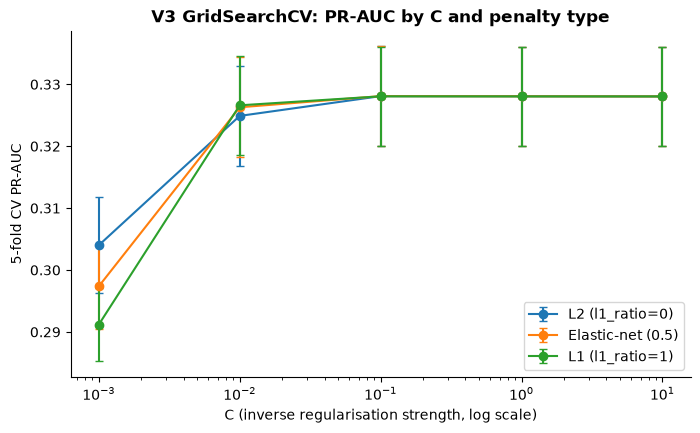

V3: PR-AUC 0.328 ± 0.008 | F1 0.250 | recall 0.660 | precision 0.154 | accuracy 0.726 (2.3s)


{'variety': 'V3',
 'description': 'GridSearch best: C=0.1, l1_ratio=0.5',
 'pr_auc_mean': np.float64(0.3280946592982438),
 'pr_auc_std': np.float64(0.008027658305977814),
 'roc_auc_mean': np.float64(0.7703953337913814),
 'roc_auc_std': np.float64(0.003543376389132784),
 'f1_mean': np.float64(0.24988940769475887),
 'f1_std': np.float64(0.0022512376893679235),
 'precision_mean': np.float64(0.15411144430068127),
 'precision_std': np.float64(0.0014901076258741922),
 'recall_mean': np.float64(0.6602276025519799),
 'recall_std': np.float64(0.006419499075810079),
 'balanced_acc_mean': np.float64(0.69558719868763),
 'balanced_acc_std': np.float64(0.003054088748884771),
 'accuracy_mean': np.float64(0.7260593457199093),
 'accuracy_std': np.float64(0.0023988677815807925),
 'seconds': 2.3}

In [7]:
# Visualise the grid: CV PR-AUC for every C, one line per penalty type
fig, ax = plt.subplots(figsize=(8, 4.5))
labels = {0.0: 'L2 (l1_ratio=0)', 0.5: 'Elastic-net (0.5)', 1.0: 'L1 (l1_ratio=1)'}
for ratio, grp in grid_table.groupby('param_l1_ratio'):
    grp = grp.sort_values('param_C')
    ax.errorbar(grp['param_C'].astype(float), grp['cv_pr_auc'], yerr=grp['cv_std'], marker='o', capsize=3, label=labels[ratio])
ax.set_xscale('log')
ax.set_xlabel('C (inverse regularisation strength, log scale)')
ax.set_ylabel('5-fold CV PR-AUC')
ax.set_title('V3 GridSearchCV: PR-AUC by C and penalty type', fontweight='bold')
ax.legend()
plt.savefig(os.path.join(MODEL_DIR, 'grid_search_pr_auc.png'), dpi=200, bbox_inches='tight')
plt.show()

best = grid.best_params_
evaluate_cv('V3', f"GridSearch best: C={best['C']}, l1_ratio={best['l1_ratio']}",
            LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=SEED, **best),
            X_train, y_train, X_test)

### Block 7: V4 SMOTE inside a pipeline (different pre-processing)
**What:** SMOTE creates *synthetic* denied applications by interpolating between real denied neighbours, until both classes are equal in size.
**Why inside a Pipeline:** the `imblearn` Pipeline applies SMOTE **only to the training folds** during CV. The validation fold and the test set stay 100% real data. Applying SMOTE before splitting would leak synthetic copies of validation rows into training: a classic mistake.
**Note:** no class weights here; SMOTE does the balancing instead.

In [8]:
smote_lr = ImbPipeline([
    ('smote', SMOTE(random_state=SEED)),
    ('lr', LogisticRegression(solver='saga', max_iter=5000, random_state=SEED, **best)),
])
evaluate_cv('V4', 'SMOTE (in-fold) + LR, best C / l1_ratio', smote_lr, X_train, y_train, X_test)

V4: PR-AUC 0.326 ± 0.008 | F1 0.247 | recall 0.670 | precision 0.152 | accuracy 0.718 (5.6s)


{'variety': 'V4',
 'description': 'SMOTE (in-fold) + LR, best C / l1_ratio',
 'pr_auc_mean': np.float64(0.3259684163383817),
 'pr_auc_std': np.float64(0.008023673436587159),
 'roc_auc_mean': np.float64(0.7690526683588497),
 'roc_auc_std': np.float64(0.0035040659223452815),
 'f1_mean': np.float64(0.24739658133612846),
 'f1_std': np.float64(0.0017723160830783813),
 'precision_mean': np.float64(0.15168503206978284),
 'precision_std': np.float64(0.0011405836664606039),
 'recall_mean': np.float64(0.6704725237062172),
 'recall_std': np.float64(0.006381001705575608),
 'balanced_acc_mean': np.float64(0.6960419078078501),
 'balanced_acc_std': np.float64(0.0026973420797624607),
 'accuracy_mean': np.float64(0.7180770723385395),
 'accuracy_std': np.float64(0.002187006516068843),
 'seconds': 5.6}

### Block 8: V5 all 107 features (handover A) + scaling in a pipeline
**What:** use the unscaled handover A (all features, before my Stage 6 selection) with a `StandardScaler` → `LogisticRegression` Pipeline.
**Why:** this directly tests my own preprocessing stage. If 107 features score clearly better than my 25, the selection threw away useful information; if they score about the same, the 25 features keep the signal with a simpler, more interpretable and more stable model.
**Pipeline step:** the scaler is fit inside each CV fold on that fold's training rows only, so no leakage.
**Role:** V5 is reported as a variety but isn't eligible as the final model, because the group compares all models on handover B (see Block 10).

In [9]:
scaled_lr_all = Pipeline([
    ('scale', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=SEED, **best)),
])
evaluate_cv('V5', 'Handover A (107 features) + StandardScaler + LR', scaled_lr_all, X_train_A, y_train_A, X_test_A)

V5: PR-AUC 0.343 ± 0.008 | F1 0.261 | recall 0.660 | precision 0.163 | accuracy 0.742 (368.2s)


{'variety': 'V5',
 'description': 'Handover A (107 features) + StandardScaler + LR',
 'pr_auc_mean': np.float64(0.3427968184755606),
 'pr_auc_std': np.float64(0.007960543168360394),
 'roc_auc_mean': np.float64(0.7795556030580142),
 'roc_auc_std': np.float64(0.004089129962130352),
 'f1_mean': np.float64(0.2612600568293847),
 'f1_std': np.float64(0.0024407939159472283),
 'precision_mean': np.float64(0.16286573498877743),
 'precision_std': np.float64(0.001531340586542683),
 'recall_mean': np.float64(0.6600236250160129),
 'recall_std': np.float64(0.007755465646804732),
 'balanced_acc_mean': np.float64(0.7040771269710353),
 'balanced_acc_std': np.float64(0.0035478935239457972),
 'accuracy_mean': np.float64(0.7420415140587868),
 'accuracy_std': np.float64(0.0018913322111068342),
 'seconds': 368.2}

### Block 8b: V6 ablation, removing the "incomplete application" shortcut
**What:** drop the `pwsrc_*` columns (prevailing-wage source, including `pwsrc_Unknown` = source not recorded) and retrain with the V3 settings.
**Why:** Stage 1 found the prevailing wage is missing for 9.3% of denied vs ~0.4% of approved applications. That's on the form at filing time (so not leakage), but a model could lean on it as a shortcut instead of learning the real drivers. The PR-AUC drop from V3 to V6 measures how much of the performance comes from this shortcut.
**Note:** V6 is a *diagnostic*, so it isn't a candidate for the final model.

In [10]:
pwsrc_cols = [c for c in X_train.columns if c.startswith('pwsrc_')]
print('Removed columns:', pwsrc_cols)
evaluate_cv('V6', 'Ablation: V3 without pwsrc_* columns',
            LogisticRegression(class_weight='balanced', solver='saga', max_iter=5000, random_state=SEED, **best),
            X_train.drop(columns=pwsrc_cols), y_train, X_test.drop(columns=pwsrc_cols))

Removed columns: ['pwsrc_Unknown', 'pwsrc_OES', 'pwsrc_Employer_Conducted']


V6: PR-AUC 0.274 ± 0.008 | F1 0.242 | recall 0.674 | precision 0.147 | accuracy 0.708 (2.8s)


{'variety': 'V6',
 'description': 'Ablation: V3 without pwsrc_* columns',
 'pr_auc_mean': np.float64(0.2742248511546507),
 'pr_auc_std': np.float64(0.007947151367906923),
 'roc_auc_mean': np.float64(0.7620129095677499),
 'roc_auc_std': np.float64(0.0034508998354948633),
 'f1_mean': np.float64(0.24175622386512044),
 'f1_std': np.float64(0.0017909393203738085),
 'precision_mean': np.float64(0.14728906549509696),
 'precision_std': np.float64(0.0012180570793326312),
 'recall_mean': np.float64(0.6741423654066572),
 'recall_std': np.float64(0.003900843763268994),
 'balanced_acc_mean': np.float64(0.692187356168855),
 'balanced_acc_std': np.float64(0.0022179984080775233),
 'accuracy_mean': np.float64(0.7077381614535996),
 'accuracy_std': np.float64(0.002200301817542782),
 'seconds': 2.8}

## 4. Comparison of the varieties

### Block 9: Comparison table and chart

,variety,description,pr_auc_mean,pr_auc_std,roc_auc_mean,f1_mean,recall_mean,precision_mean,balanced_acc_mean,accuracy_mean
0,V0,Dummy: always approve,0.069,0.000,0.500,0.000,0.000,0.000,0.500,0.931
1,V1,Plain LR (no class weights),0.332,0.009,0.769,0.192,0.108,0.861,0.553,0.937
2,V2,LR + class_weight=balanced,0.328,0.008,0.770,0.250,0.660,0.154,0.696,0.726
3,V3,"GridSearch best: C=0.1, l1_ratio=0.5",0.328,0.008,0.770,0.250,0.660,0.154,0.696,0.726
4,V4,"SMOTE (in-fold) + LR, best C / l1_ratio",0.326,0.008,0.769,0.247,0.670,0.152,0.696,0.718
5,V5,Handover A (107 features) + StandardScaler + LR,0.343,0.008,0.780,0.261,0.660,0.163,0.704,0.742
6,V6,Ablation: V3 without pwsrc_* columns,0.274,0.008,0.762,0.242,0.674,0.147,0.692,0.708


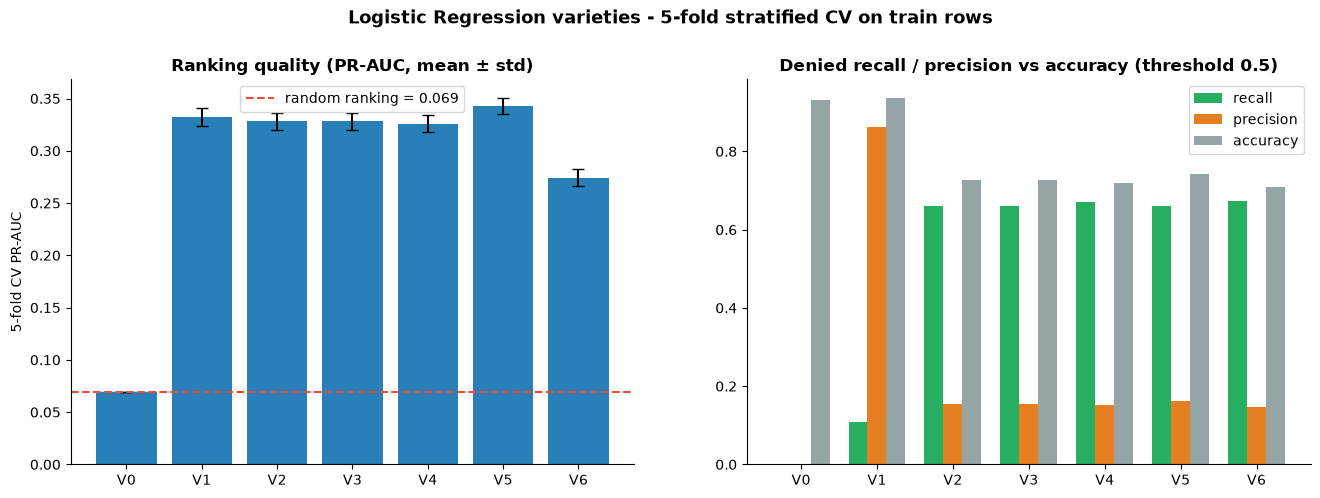

In [11]:
comparison = pd.DataFrame(results)
comparison.to_csv(os.path.join(MODEL_DIR, 'cv_varieties.csv'), index=False)
show = comparison[['variety', 'description', 'pr_auc_mean', 'pr_auc_std', 'roc_auc_mean', 'f1_mean',
                   'recall_mean', 'precision_mean', 'balanced_acc_mean', 'accuracy_mean']]
display(show.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(len(comparison))
axes[0].bar(x, comparison['pr_auc_mean'], yerr=comparison['pr_auc_std'], capsize=4, color='#2980b9')
axes[0].axhline(y_train.mean(), color='#e74c3c', linestyle='--', label=f'random ranking = {y_train.mean():.3f}')
axes[0].set_xticks(x, comparison['variety'])
axes[0].set_ylabel('5-fold CV PR-AUC')
axes[0].set_title('Ranking quality (PR-AUC, mean ± std)', fontweight='bold')
axes[0].legend()
w = 0.25
for i, (m, c) in enumerate([('recall_mean', '#27ae60'), ('precision_mean', '#e67e22'), ('accuracy_mean', '#95a5a6')]):
    axes[1].bar(x + (i - 1) * w, comparison[m], w, label=m.replace('_mean', ''), color=c)
axes[1].set_xticks(x, comparison['variety'])
axes[1].set_title('Denied recall / precision vs accuracy (threshold 0.5)', fontweight='bold')
axes[1].legend()
plt.suptitle('Logistic Regression varieties - 5-fold stratified CV on train rows', fontsize=13, fontweight='bold', y=1.02)
plt.savefig(os.path.join(MODEL_DIR, 'cv_varieties_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

### Block 10: Choose the best variety
**Rule (decided before looking at the test set):** the final model must use **handover B**, because the group compares all six models on the same 25 selected features (README §5, rule 1). So the candidates are **V1–V4**:
- V0 is the baseline;
- V5 is a preprocessing experiment (all 107 features from handover A), reported in the table to test my own Stage 6;
- V6 is a diagnostic ablation.

Among V1–V4 the highest mean CV PR-AUC wins. If several are within one standard deviation of it, prefer in this order: the tuned model (V3), then class weights (V2), then plain (V1), then SMOTE (V4, synthetic data).

In [12]:
candidates = comparison[comparison['variety'].isin(['V1', 'V2', 'V3', 'V4'])].sort_values('pr_auc_mean', ascending=False)
top = candidates.iloc[0]
preference = ['V3', 'V2', 'V1', 'V4']                # tie-break order (see the rule above)
close = candidates[candidates['pr_auc_mean'] >= top['pr_auc_mean'] - top['pr_auc_std']]
best_name = sorted(close['variety'], key=preference.index)[0]
best_estimator, best_X_train, best_X_test = fitted[best_name]
print(f'Highest CV PR-AUC among handover-B varieties: {top.variety} ({top.pr_auc_mean:.4f} ± {top.pr_auc_std:.4f})')
print('Within one std of the top:', list(close['variety']))
print(f'Selected variety: {best_name} - {comparison.set_index("variety").loc[best_name, "description"]}')

Highest CV PR-AUC among handover-B varieties: V1 (0.3321 ± 0.0087)
Within one std of the top: ['V1', 'V3', 'V2', 'V4']
Selected variety: V3 - GridSearch best: C=0.1, l1_ratio=0.5


## 5. Decision threshold

A probability model outputs P(denied). The default rule "denied if P > 0.5" is arbitrary for imbalanced data. We choose the threshold that **maximises F1 for Denied**, using **out-of-fold** predictions on the train rows: every train row is predicted by a model that never saw it. The test set is *not* used for this choice.

### Block 11: Threshold tuning with out-of-fold predictions

Out-of-fold PR-AUC: 0.3279
Best threshold = 0.690 -> OOF F1 0.331 (precision 0.290, recall 0.386)
Default 0.5   -> OOF F1 0.250 (precision 0.154, recall 0.660)


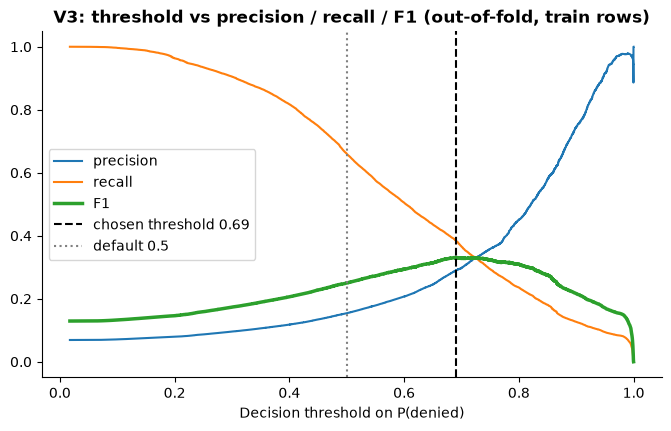

In [13]:
oof_proba = cross_val_predict(best_estimator, best_X_train, y_train, cv=CV, method='predict_proba', n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
best_i = int(np.argmax(f1s))
THRESHOLD = float(thr[best_i])
print(f'Out-of-fold PR-AUC: {average_precision_score(y_train, oof_proba):.4f}')
print(f'Best threshold = {THRESHOLD:.3f} -> OOF F1 {f1s[best_i]:.3f} (precision {prec[best_i]:.3f}, recall {rec[best_i]:.3f})')
default = (oof_proba >= 0.5).astype(int)
print(f'Default 0.5   -> OOF F1 {f1_score(y_train, default):.3f} (precision {precision_score(y_train, default):.3f}, '
      f'recall {recall_score(y_train, default):.3f})')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thr, prec[:-1], label='precision')
ax.plot(thr, rec[:-1], label='recall')
ax.plot(thr, f1s, label='F1', linewidth=2.5)
ax.axvline(THRESHOLD, color='black', linestyle='--', label=f'chosen threshold {THRESHOLD:.2f}')
ax.axvline(0.5, color='grey', linestyle=':', label='default 0.5')
ax.set_xlabel('Decision threshold on P(denied)')
ax.set_title(f'{best_name}: threshold vs precision / recall / F1 (out-of-fold, train rows)', fontweight='bold')
ax.legend()
plt.savefig(os.path.join(MODEL_DIR, 'threshold_tuning.png'), dpi=200, bbox_inches='tight')
plt.show()

## 6. Final evaluation on the test set (used once)

### Block 12: Fit on all train rows, then evaluate on the 70,970 untouched test rows

In [14]:
final_model = best_estimator.fit(best_X_train, y_train)
lr_params = (final_model.named_steps['lr'] if hasattr(final_model, 'named_steps') else final_model).get_params()
test_proba = final_model.predict_proba(best_X_test)[:, 1]
test_pred = (test_proba >= THRESHOLD).astype(int)

test_metrics = {
    'member': 'IT25100285', 'model': 'Logistic Regression', 'variety': best_name,
    'dataset': 'A' if best_name == 'V5' else 'B',
    'params': {k: lr_params[k] for k in ('C', 'l1_ratio', 'class_weight', 'solver')},
    'threshold': round(THRESHOLD, 4),
    'cv_pr_auc_mean': round(float(comparison.set_index('variety').loc[best_name, 'pr_auc_mean']), 4),
    'cv_pr_auc_std': round(float(comparison.set_index('variety').loc[best_name, 'pr_auc_std']), 4),
    'test_pr_auc': round(average_precision_score(y_test, test_proba), 4),
    'test_roc_auc': round(roc_auc_score(y_test, test_proba), 4),
    'test_f1_denied': round(f1_score(y_test, test_pred), 4),
    'test_precision_denied': round(precision_score(y_test, test_pred), 4),
    'test_recall_denied': round(recall_score(y_test, test_pred), 4),
    'test_balanced_accuracy': round(balanced_accuracy_score(y_test, test_pred), 4),
    'test_accuracy': round(accuracy_score(y_test, test_pred), 4),
    'baseline_accuracy_always_approve': round(1 - float(y_test.mean()), 4),
}
with open(os.path.join(MODEL_DIR, 'test_metrics.json'), 'w') as f:
    json.dump(test_metrics, f, indent=2)
print(json.dumps(test_metrics, indent=2))
print(classification_report(y_test, test_pred, target_names=['Approved (0)', 'Denied (1)'], digits=3))

{
  "member": "IT25100285",
  "model": "Logistic Regression",
  "variety": "V3",
  "dataset": "B",
  "params": {
    "C": 0.1,
    "l1_ratio": 0.5,
    "class_weight": "balanced",
    "solver": "saga"
  },
  "threshold": 0.6899,
  "cv_pr_auc_mean": 0.3281,
  "cv_pr_auc_std": 0.008,
  "test_pr_auc": 0.3212,
  "test_roc_auc": 0.7666,
  "test_f1_denied": 0.3285,
  "test_precision_denied": 0.2856,
  "test_recall_denied": 0.3863,
  "test_balanced_accuracy": 0.6573,
  "test_accuracy": 0.8908,
  "baseline_accuracy_always_approve": 0.9309
}
              precision    recall  f1-score   support

Approved (0)      0.953     0.928     0.941     66065
  Denied (1)      0.286     0.386     0.328      4905

    accuracy                          0.891     70970
   macro avg      0.619     0.657     0.635     70970
weighted avg      0.907     0.891     0.898     70970



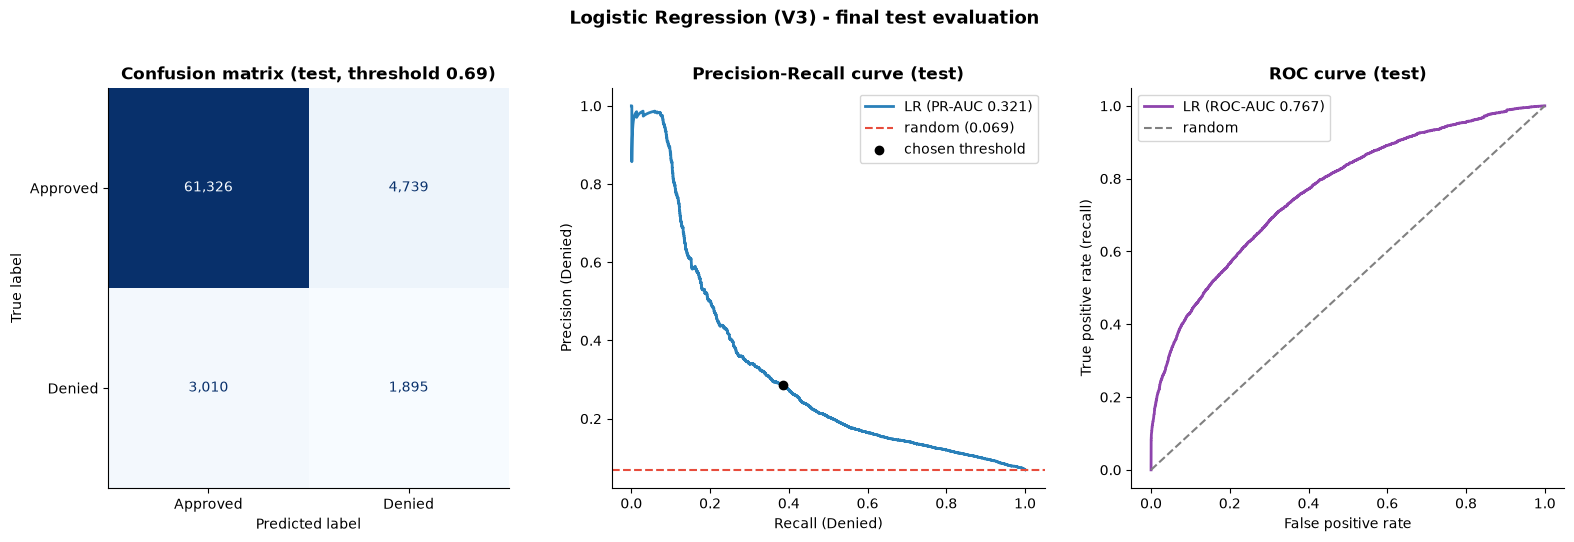

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.2))
ConfusionMatrixDisplay(confusion_matrix(y_test, test_pred), display_labels=['Approved', 'Denied']).plot(
    ax=axes[0], cmap='Blues', values_format=',', colorbar=False)
axes[0].set_title(f'Confusion matrix (test, threshold {THRESHOLD:.2f})', fontweight='bold')

p, r, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(r, p, color='#2980b9', linewidth=2, label=f"LR (PR-AUC {test_metrics['test_pr_auc']:.3f})")
axes[1].axhline(y_test.mean(), color='#e74c3c', linestyle='--', label=f'random ({y_test.mean():.3f})')
axes[1].scatter([test_metrics['test_recall_denied']], [test_metrics['test_precision_denied']], color='black', zorder=5,
                label='chosen threshold')
axes[1].set_xlabel('Recall (Denied)')
axes[1].set_ylabel('Precision (Denied)')
axes[1].set_title('Precision-Recall curve (test)', fontweight='bold')
axes[1].legend()

fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[2].plot(fpr, tpr, color='#8e44ad', linewidth=2, label=f"LR (ROC-AUC {test_metrics['test_roc_auc']:.3f})")
axes[2].plot([0, 1], [0, 1], color='grey', linestyle='--', label='random')
axes[2].set_xlabel('False positive rate')
axes[2].set_ylabel('True positive rate (recall)')
axes[2].set_title('ROC curve (test)', fontweight='bold')
axes[2].legend()
plt.suptitle(f'Logistic Regression ({best_name}) - final test evaluation', fontsize=13, fontweight='bold', y=1.03)
plt.savefig(os.path.join(MODEL_DIR, 'test_evaluation.png'), dpi=200, bbox_inches='tight')
plt.show()

## 7. Interpretation: what drives denial?

### Block 13: Coefficients as odds ratios
`exp(coefficient)` = an **odds ratio**: how the odds of denial are multiplied.
- **Continuous / ordinal features:** the effect of a **+1 standard deviation** increase.
- **0/1 flags and one-hot columns:** the effect of switching **0 → 1**. If a scaler sits inside the pipeline, the flag was standardised too, so we convert back: `exp(coef / scale)`.

Above 1 means a higher denial risk; below 1 means a lower risk. Categories present in < 0.5% of train rows are left out of the chart: with so few rows their odds ratios are unstable (huge or tiny by chance). They're listed separately.

Non-zero coefficients: 25 of 25
Rare categories (< 0.5% of rows, unstable, not plotted):
                          odds_ratio  train_prevalence
soc_47                        3.0652            0.0038
pwsrc_Employer_Conducted      4.6018            0.0014


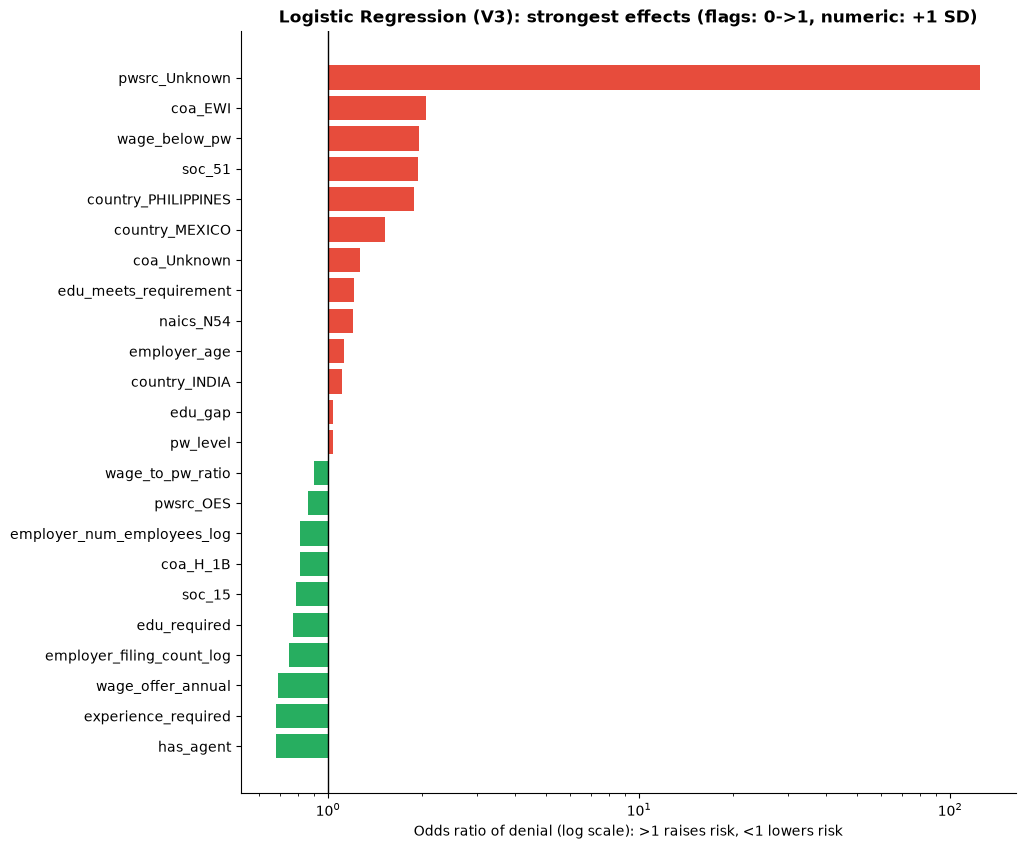

,odds_ratio,coefficient,type,train_prevalence
edu_gap,1.037,0.036,+1 SD,NaN
country_INDIA,1.109,0.104,0->1 flag,0.553
employer_age,1.127,0.119,+1 SD,NaN
naics_N54,1.206,0.187,0->1 flag,0.314
edu_meets_requirement,1.215,0.195,0->1 flag,0.508
coa_Unknown,1.266,0.236,0->1 flag,0.059
country_MEXICO,1.524,0.421,0->1 flag,0.024
country_PHILIPPINES,1.894,0.639,0->1 flag,0.023
soc_51,1.949,0.667,0->1 flag,0.024
wage_below_pw,1.952,0.669,0->1 flag,0.008


In [16]:
lr_step = final_model.named_steps['lr'] if hasattr(final_model, 'named_steps') else final_model
scale = (pd.Series(final_model.named_steps['scale'].scale_, index=best_X_train.columns)
         if hasattr(final_model, 'named_steps') and 'scale' in final_model.named_steps else pd.Series(1.0, index=best_X_train.columns))
coef = pd.Series(lr_step.coef_[0], index=best_X_train.columns)
is_binary = best_X_train.isin([0, 1]).all()
prevalence = best_X_train.mean()
odds = pd.Series(np.where(is_binary, np.exp(coef / scale), np.exp(coef)), index=coef.index)
table = pd.DataFrame({'odds_ratio': odds, 'coefficient': coef, 'type': np.where(is_binary, '0->1 flag', '+1 SD'),
                      'train_prevalence': np.where(is_binary, prevalence, np.nan)}).sort_values('odds_ratio')
table.to_csv(os.path.join(MODEL_DIR, 'coefficients.csv'))
stable = table[(table['type'] == '+1 SD') | (table['train_prevalence'] >= 0.005)]
rare = table[(table['type'] == '0->1 flag') & (table['train_prevalence'] < 0.005)]
print(f'Non-zero coefficients: {(coef != 0).sum()} of {len(coef)}')
print('Rare categories (< 0.5% of rows, unstable, not plotted):')
print(rare[['odds_ratio', 'train_prevalence']].round(4).to_string())

shown = pd.concat([stable.head(12), stable.tail(12)])['odds_ratio']
fig, ax = plt.subplots(figsize=(10, 0.35 * len(shown) + 1.5))
ax.barh(shown.index, shown.values - 1, left=1, color=np.where(shown.values > 1, '#e74c3c', '#27ae60'))
ax.axvline(1, color='black', linewidth=1)
ax.set_xscale('log')
ax.set_xlabel('Odds ratio of denial (log scale): >1 raises risk, <1 lowers risk')
ax.set_title(f'Logistic Regression ({best_name}): strongest effects (flags: 0->1, numeric: +1 SD)', fontweight='bold')
plt.savefig(os.path.join(MODEL_DIR, 'coefficients_odds_ratios.png'), dpi=200, bbox_inches='tight')
plt.show()
stable.tail(12).round(3)

### Block 14: Save the model
The fitted model, the threshold and the feature list are saved, so the group comparison (and the viva demo) can reload the model without retraining.

In [17]:
joblib.dump({'model': final_model, 'threshold': THRESHOLD, 'features': list(best_X_train.columns),
             'variety': best_name}, os.path.join(MODEL_DIR, 'model.joblib'))
reloaded = joblib.load(os.path.join(MODEL_DIR, 'model.joblib'))
check = (reloaded['model'].predict_proba(best_X_test)[:, 1] >= reloaded['threshold']).astype(int)
assert (check == test_pred).all()
print('Saved and verified:', sorted(os.listdir(MODEL_DIR)))

Saved and verified: ['coefficients.csv', 'coefficients_odds_ratios.png', 'cv_varieties.csv', 'cv_varieties_comparison.png', 'grid_search_pr_auc.png', 'grid_search_results.csv', 'model.joblib', 'test_evaluation.png', 'test_metrics.json', 'threshold_tuning.png']


## 8. Conclusion

### Results of the varieties (5-fold stratified CV on the 283,879 train rows)

| Variety | What changed | CV PR-AUC (mean ± std) | Recall (Denied) | Precision (Denied) | Accuracy |
|---|---|---|---|---|---|
| V0 | Always approve (baseline) | 0.069 ± 0.000 | 0.000 | 0.000 | 0.931 |
| V1 | Plain LR | 0.332 ± 0.009 | 0.108 | 0.861 | 0.937 |
| V2 | `class_weight='balanced'` | 0.328 ± 0.008 | 0.660 | 0.154 | 0.726 |
| **V3** | **GridSearchCV best (C=0.1, l1_ratio=0.5) = final model** | **0.328 ± 0.008** | 0.660 | 0.154 | 0.726 |
| V4 | SMOTE inside the pipeline | 0.326 ± 0.008 | 0.670 | 0.152 | 0.718 |
| V5 | Experiment: all 107 features (handover A) + scaler | 0.343 ± 0.008 | 0.660 | 0.163 | 0.742 |
| V6 | Ablation: V3 without `pwsrc_*` | 0.274 ± 0.008 | 0.674 | 0.147 | 0.708 |

*(Recall, precision and accuracy use the default 0.5 threshold.)*

### Findings
1. **Accuracy trap.** V0 scores 93.1% accuracy but catches **zero** denials, and plain LR (V1) reaches 93.7% accuracy while catching only 10.8% of denials. Accuracy is not a valid metric for this imbalanced problem; PR-AUC and F1/recall for the Denied class are.
2. **Class weights change the decision threshold, not the ranking.** From V1 to V2, recall jumps from 0.108 to 0.660 (precision falls from 0.861 to 0.154), but PR-AUC stays about the same (0.332 vs 0.328). Re-weighting moves where the model draws the line; it doesn't make it better at ordering applications by risk.
3. **Hyperparameter tuning (V3).** 15 combinations × 5 folds. Very strong regularisation underfits: at `C=0.001`, PR-AUC drops to 0.291–0.304 (L1 is worst, because it zeroes out too many coefficients). From `C=0.1` upward every penalty type reaches ~0.328, a plateau. Train and CV PR-AUC are almost identical (0.3284 vs 0.3281), so the model does **not overfit**: with 284k rows and 25 features there's little for regularisation to fix. Best: `C=0.1`, `l1_ratio=0.5` (elastic-net); all 25 coefficients stay non-zero.
4. **SMOTE vs class weights (V4 vs V3).** SMOTE gives no improvement (0.326 vs 0.328) and costs more (synthetic rows, 2× training time). Class weights are the simpler, equally effective way to handle the imbalance.
5. **Choosing the final model.** The final model must use handover B, because the group compares all six models on the same 25 features. V1–V4 are all within one standard deviation of each other (0.326–0.332), so by the pre-set rule the **tuned model V3** is selected: it's regularised, handles the imbalance with class weights and was chosen by GridSearchCV.
6. **Testing my own feature selection (V5).** Using all 107 features scores higher than my 25 (0.343 vs 0.328, about 2 standard deviations). Mutual information scores each feature *on its own*, so it missed small *combined* signals from the many one-hot columns that a linear model can add together. **Trade-off:** the 25 features keep 96% of the PR-AUC with 4× fewer inputs, so the model is far easier to interpret, trains much faster (2 s vs 6 min per CV run) and stays comparable with the other group models.
7. **Shortcut ablation (V6 vs V3).** Without the prevailing-wage-source columns, PR-AUC falls from 0.328 to 0.274 (−16%). In the final model, `pwsrc_Unknown` (prevailing wage source not recorded) multiplies the odds of denial by about **125×**. Incomplete applications are a genuine, filing-time reason for denial (not leakage), but a substantial part of the model's skill comes from this one signal.
8. **Threshold.** Using out-of-fold predictions on the train rows, the F1-best threshold is **0.690** (instead of 0.5): out-of-fold F1 rises from 0.250 to 0.331.
9. **Final test result (V3, threshold 0.690, 70,970 untouched test rows, used once):**

   | Metric | Value |
   |---|---|
   | PR-AUC | **0.321** (4.6× the random baseline of 0.069) |
   | ROC-AUC | 0.767 |
   | F1 (Denied) | 0.328 |
   | Precision (Denied) | 0.286 |
   | Recall (Denied) | 0.386 (1,895 of 4,905 denials caught) |
   | Accuracy | 0.891 (vs 0.931 "always approve": lower, because the model now flags denials) |

   The test PR-AUC (0.321) is close to the CV PR-AUC (0.328), so the result **generalises**; there's no overfitting.
10. **What drives denial (odds ratios; flags = 0 → 1, numeric = +1 standard deviation).**
    - *Raise the risk:* prevailing-wage source missing (`pwsrc_Unknown`, ~125×); entered without inspection (`coa_EWI`, 2.1×); **offered wage below the prevailing wage** (`wage_below_pw`, 2.0×, matching the PERM wage rule); production occupations (`soc_51`, 1.9×); citizenship Philippines (1.9×) and Mexico (1.5×).
    - *Lower the risk:* filed through an attorney/agent (`has_agent`, 0.68×); job requires experience (0.68×); a higher offered wage (0.69× per SD); employers who file more often (0.75× per SD) and larger employers (0.82× per SD); higher required education (0.77× per SD); computer occupations (`soc_15`, 0.79×); H-1B holders (0.82×).
    - **Conditional vs marginal effect:** `edu_meets_requirement` shows 1.2× (slightly higher risk) in the model, although on its own it goes with a *lower* denial rate (4.2% vs 9.7%). The coefficient is the effect *after adjusting* for the other features, especially `edu_required`, with which it is strongly correlated, so a single coefficient shouldn't be read in isolation.

    Overall the directions make domain sense, which supports the model's validity.

### Limitations
- **Linear decision boundary:** LR can't capture interactions or threshold effects unless they were engineered as features, which is why its PR-AUC (0.321) is moderate. Tree models are expected to score higher.
- **Low precision:** at the chosen threshold, about 7 of every 10 "denied" predictions are wrong (precision 0.29), so the model suits flagging applications for **review**, not automatic decisions.
- **Shortcut dependence:** the model relies heavily on `pwsrc_Unknown` (see V6).
- **Proxies and drift:** some features partly encode the form version and year (missingness patterns), and the denial rate drifted from 10–14% (2011–13) to 5–6% (2014–16), so performance on future applications may differ.
- **Fairness:** citizenship features affect predictions (e.g. Philippines 1.9×, Mexico 1.5×), which must be discussed in the report's ethics section.

### Improvements
- Add interaction terms or spline features (e.g. wage ratio × occupation) to give LR some non-linearity.
- Choose the threshold from the real cost of a missed denial vs a false alarm instead of maximising F1.
- Report results with and without the `pwsrc_*` shortcut, and compare against tree-based models (Random Forest, XGBoost) in the group comparison.
- Use an embedded L1 selection or a larger *k* in Stage 6, since V5 showed that low-MI features still add signal for a linear model.
